# Demonstrate Use

- get_initial_plan()
- instantiate the recalculator object
- calculate how many minutes of charge are still needed
- after interval passes, get new plan with updated info
- repeat
- return combined schedule


In [1]:
import os
os.chdir("/Users/jen/watttime-python-client")

import watttime.api as wt
from datetime import timedelta, datetime
from pytz import UTC
import pandas as pd

from watttime.api import WattTimeOptimizer,WattTimeRecalculator,WattTimeForecast
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_forecast_dataframe(
          start_time: datetime = datetime(2025, 1, 1, hour=21, second=1, tzinfo=UTC),
          end_time: datetime = datetime(2025, 1, 2, hour=8, second=1, tzinfo=UTC),
          horizon_hours: int = 12,
          region: str = 'CAISO_NORTH'
        ) -> pd.DataFrame:
        try:
            username = os.getenv("WATTTIME_USER")
            password = os.getenv("WATTTIME_PASSWORD")
            
            if not username or not password:
                raise ValueError("WattTime credentials not found in environment variables")
                
            wth = wt.WattTimeForecast(username=username, password=password)
            
            forecast_dataframe = wth.get_historical_forecast_pandas(
                start=start_time + timedelta(minutes=5),
                end=end_time,
                region=region,
                signal_type="co2_moer",
                horizon_hours=horizon_hours
            )
        except Exception as e:
            raise RuntimeError(f"Error retrieving forecast data: {str(e)}")
        
        return forecast_dataframe

In [3]:
start_time = datetime(2025, 4, 15, hour=17, minute=30, second=0, tzinfo=UTC)
end_time = datetime(2025, 4, 15, hour=22, minute=40, second=0, tzinfo=UTC)
region = 'CAISO_NORTH'

moers = get_forecast_dataframe(start_time=start_time, end_time=end_time, region=region)

requery_dates_ten = moers.generated_at.unique()[0::2] #10 minute intervals
requery_dates_thirty = moers.generated_at.unique()[0::6] #30 minute intervals


def make_moer_list(requery_dates):
    moers_list = []
    for d in requery_dates:
        temp = moers[moers.generated_at == d]
        moers_list.append(temp)
    return moers_list


In [36]:
fitted_recalculator_ten = wt.RequerySimulator(
                                    make_moer_list(requery_dates_ten),
                                    requery_dates_ten,
                                    region = region,
                                    window_start = start_time,
                                    window_end = end_time,
                                    usage_time_required_minutes = 76.459084,
                                    usage_power_kw = 26.1375
                                    ).simulate()

fitted_recalculator_thirty = wt.RequerySimulator(
                                    make_moer_list(requery_dates_thirty),
                                    requery_dates_thirty,
                                    region = region,
                                    window_start = start_time,
                                    window_end = end_time,
                                    usage_time_required_minutes = 76.459084,
                                    usage_power_kw = 26.1375
                                    ).simulate()

== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==
== Simple fit! ==


/Users/jen/watttime-python-client/watttime/api.py:728: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  forecast_df.index = pd.to_datetime(forecast_df.index)


<Axes: xlabel='point_time'>

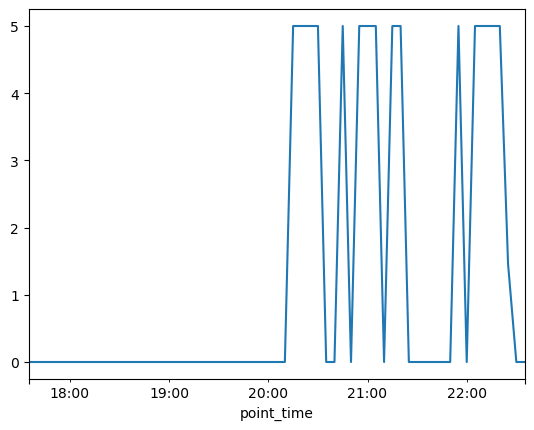

In [37]:
fitted_recalculator_ten.get_combined_schedule()["usage"].plot(kind='line')

<Axes: xlabel='point_time'>

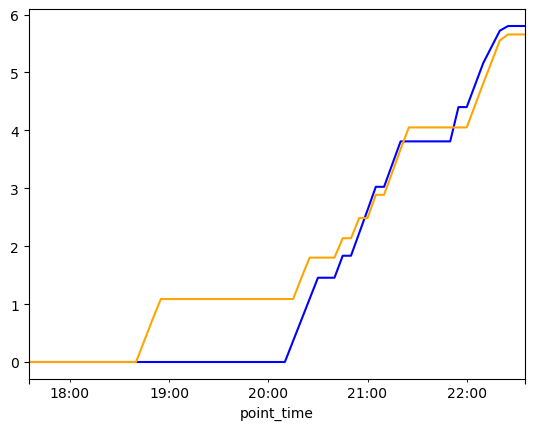

In [38]:
fitted_recalculator_ten.get_combined_schedule()["emissions_co2e_lb"].cumsum().plot(kind='line', color = 'blue')
fitted_recalculator_thirty.get_combined_schedule()["emissions_co2e_lb"].cumsum().plot(kind='line', color = 'orange')

<Axes: xlabel='point_time'>

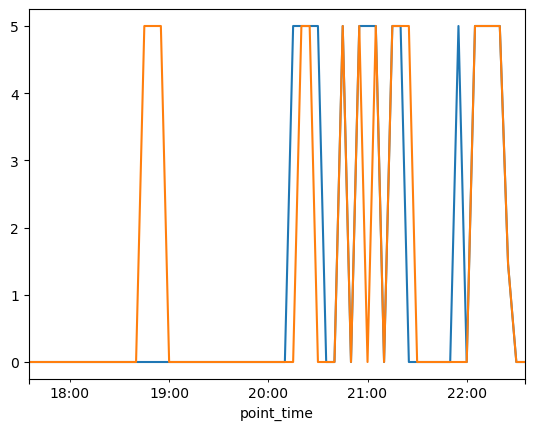

In [39]:
fitted_recalculator_ten.get_combined_schedule()["usage"].plot(kind='line')
fitted_recalculator_thirty.get_combined_schedule()["usage"].plot(kind='line')

<Axes: xlabel='point_time'>

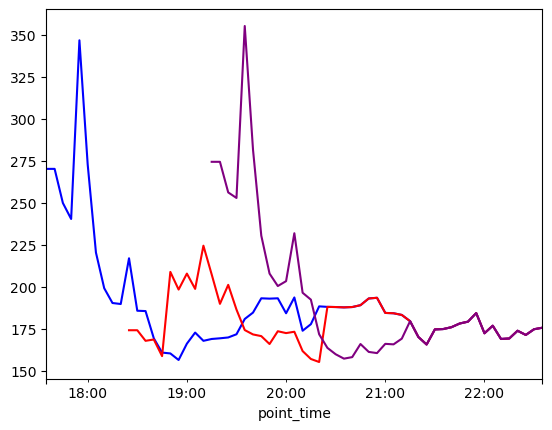

In [40]:
fitted_recalculator_ten.all_schedules[0][0]["pred_moer"].plot(kind='line', color = 'blue')
fitted_recalculator_ten.all_schedules[5][0]["pred_moer"].plot(kind='line', color = 'red')
fitted_recalculator_ten.all_schedules[10][0]["pred_moer"].plot(kind='line', color = 'purple')
#fitted_recalculator_thirty.get_combined_schedule()["emissions_co2e_lb"].cumsum().plot(kind='line', color = 'orange')